In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Raw data load 
df = pd.read_csv('../Data/raw/heart_disease_health_indicators_BRFSS2015 (1).csv')

print("Data Shape:", df.shape)
df.head()

Data Shape: (253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# Phase 1: Environment Setup & Data Loading

## Overview
In this initial step, we set up the data science environment by importing the required libraries for data analysis, visualization, and preprocessing. We then load the raw dataset to inspect its structure and dimensions before starting the preprocessing pipeline.

### Steps Performed:
1. **Import Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn` modules.
2. **Load Dataset:** Load the `heart_disease_health_indicators_BRFSS2015.csv` file from the raw data directory.
3. **Initial Inspection:** Verify the shape (rows and columns) and preview the top rows of the dataset.


# Phase 2: Train-Test Split (Preventing Data Leakage)

## Overview
Before applying any data imputation, transformation, or cleaning, we split the dataset into Training (80%) and Testing (20%) sets. 

### Why Split First?
Fitting imputation or scaling parameters on the full dataset before splitting leads to **data leakage**, resulting in overly optimistic model evaluations. By splitting early, all preprocessing rules will be learned strictly from the training set.

### Steps Performed:
1. Separate features (`X`) and the target variable (`y = HeartDiseaseorAttack`).
2. Perform an 80/20 train-test split with stratification to maintain target class proportions.

In [5]:
# Separate target variable from features
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print(f"Training Target Class Distribution:\n{y_train.value_counts(normalize=True)}")

Training Features Shape: (202944, 21)
Testing Features Shape:  (50736, 21)
Training Target Class Distribution:
HeartDiseaseorAttack
0.0    0.905816
1.0    0.094184
Name: proportion, dtype: float64


# Phase 3: Data Audit & Cleaning

## Overview
In this step, we perform a thorough data quality audit on the training set (`X_train`) to identify missing values, check summary statistics, and detect duplicate rows or invalid data ranges before proceeding to EDA.

### Steps Performed:
1. Check for missing/null values across all features.
2. Evaluate summary statistics (min, max, mean, standard deviation) for potential anomalies or outliers.
3. Check and remove any duplicate entries from the training set.

In [6]:
# 1. Missing values check
missing_vals = X_train.isnull().sum()
print("Missing values per column in X_train:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found!")

# 2. Check for duplicate rows in training set
duplicates_count = X_train.duplicated().sum()
print(f"\nDuplicate rows in X_train: {duplicates_count}")

# 3. Summary statistics for range/outlier checks
print("\nSummary Statistics of X_train:")
X_train.describe().T[['mean', 'std', 'min', '50%', 'max']]

Missing values per column in X_train:
No missing values found!

Duplicate rows in X_train: 17905

Summary Statistics of X_train:


,mean,std,min,50%,max
HighBP,0.429232,0.494968,0.0,0.0,1.0
HighChol,0.424753,0.494307,0.0,0.0,1.0
CholCheck,0.962773,0.189318,0.0,1.0,1.0
BMI,28.381056,6.610957,12.0,27.0,98.0
Smoker,0.443122,0.496756,0.0,0.0,1.0
Stroke,0.040346,0.196770,0.0,0.0,1.0
Diabetes,0.297353,0.698492,0.0,0.0,2.0
PhysActivity,0.756815,0.429007,0.0,1.0,1.0
Fruits,0.634727,0.481508,0.0,1.0,1.0
Veggies,0.811884,0.390806,0.0,1.0,1.0


# Phase 4: Duplicate Removal & Exploratory Data Analysis (EDA)

## Overview
We remove duplicate rows from the training dataset (`X_train` and `y_train`) to ensure model training relies on unique instances. Following the cleanup, we explore feature distributions, class imbalances in the target variable, and correlations among health indicators.

### Steps Performed:
1. Deduplicate training data synchronized with target labels.
2. Plot target variable distribution (`HeartDiseaseorAttack`).
3. Visualize continuous features (e.g., `BMI`) distribution.
4. Generate a Correlation Heatmap to observe relationships between features.

Shape of X_train after deduplication: (185771, 21)


C:\Users\nilof\AppData\Local\Temp\ipykernel_5732\3284397797.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='coolwarm')


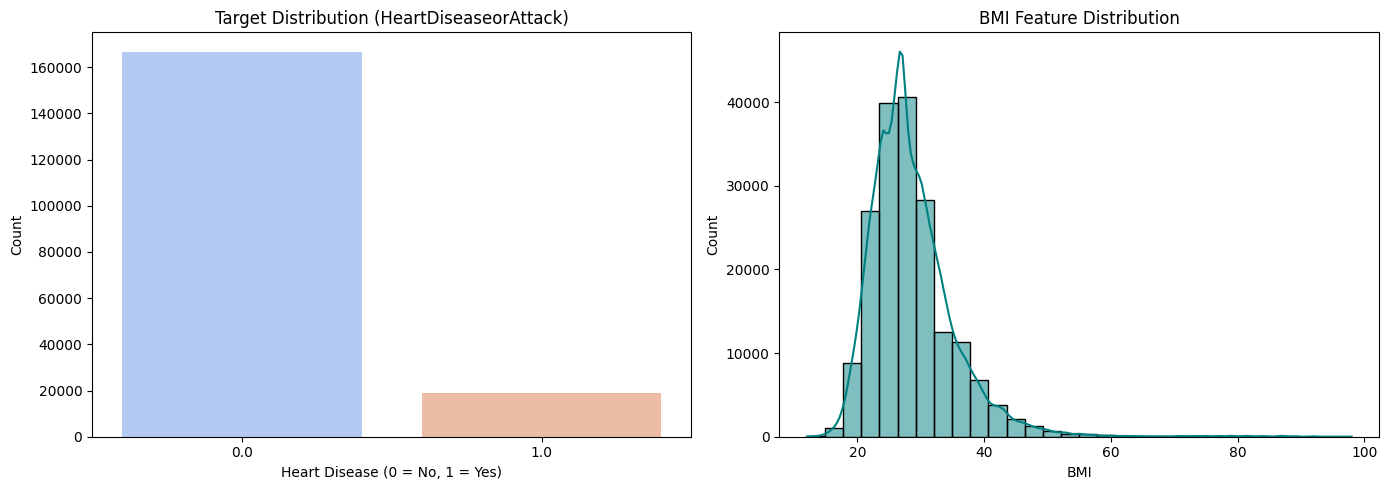

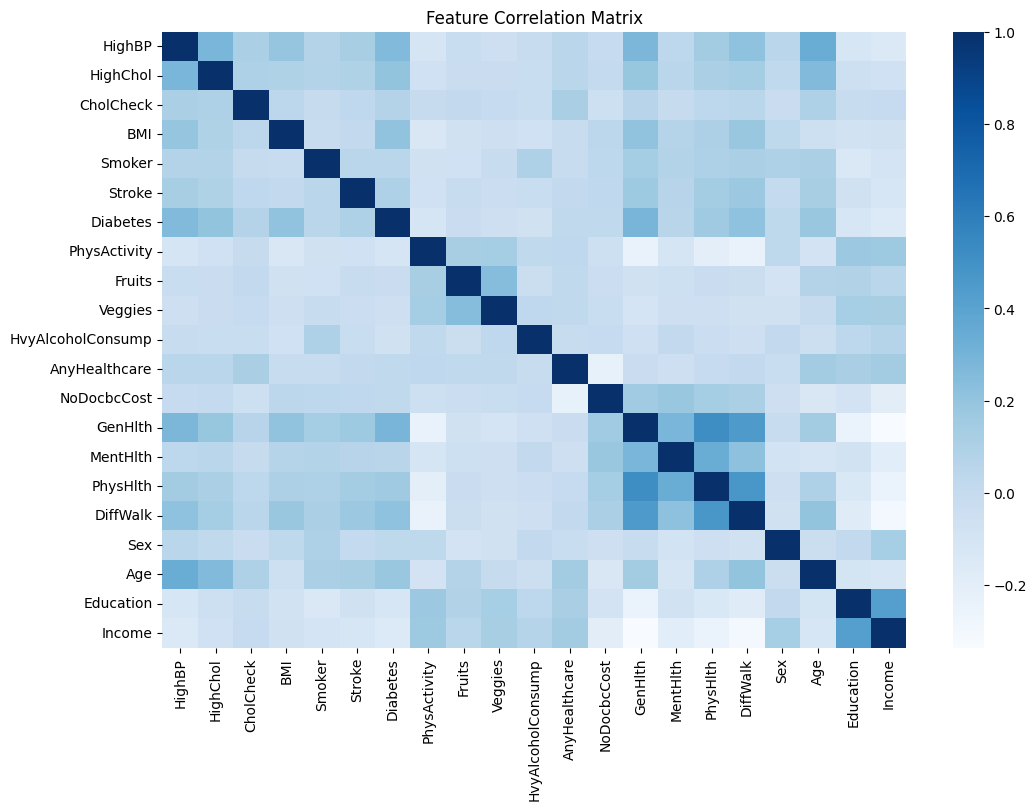

In [7]:
# 1. Deduplicate X_train and synchronize y_train
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined = train_combined.drop_duplicates()

# Re-split X_train and y_train after deduplication
X_train = train_combined.drop(columns=['HeartDiseaseorAttack'])
y_train = train_combined['HeartDiseaseorAttack']

print(f"Shape of X_train after deduplication: {X_train.shape}")

# 2. EDA Visualizations Setup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Variable Distribution
sns.countplot(x=y_train, ax=axes[0], palette='coolwarm')
axes[0].set_title('Target Distribution (HeartDiseaseorAttack)')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

# BMI Distribution
sns.histplot(X_train['BMI'], kde=True, bins=30, ax=axes[1], color='teal')
axes[1].set_title('BMI Feature Distribution')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap='Blues', annot=False, cbar=True)
plt.title('Feature Correlation Matrix')
plt.show()

# Phase 5: Exporting Cleaned & Processed Datasets

## Overview
In this final step, we export the split and cleaned datasets to the `Data/processed/` directory. This ensures that down-stream modeling (e.g., Student 3's task) can directly consume preprocessed data without risk of data leakage.

### Saved Files:
* `X_train_clean.csv` & `y_train_clean.csv`
* `X_test_clean.csv` & `y_test_clean.csv`

In [8]:
import os

# Processed directory path create karein agar exist nahi karti
processed_dir = '../Data/processed'
os.makedirs(processed_dir, exist_ok=True)

# Datasets export karein
X_train.to_csv(f'{processed_dir}/X_train_clean.csv', index=False)
y_train.to_csv(f'{processed_dir}/y_train_clean.csv', index=False)
X_test.to_csv(f'{processed_dir}/X_test_clean.csv', index=False)
y_test.to_csv(f'{processed_dir}/y_test_clean.csv', index=False)

print("✅ All clean datasets successfully exported to 'Data/processed/' directory!")

✅ All clean datasets successfully exported to 'Data/processed/' directory!
